In [1]:
import duckdb 
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from helper_functions.chart_utils import show_plot

# Electric Vehicle Insights and Visualizations

## Introduction of Analysis and Business Context

## Objectives / Questions
1) Which fifteen states have the most EV registrations? (ArcGIS)
1a) To further this exploration, which states prefer PHEVs versus BEVs in the United States?
2) Which ten counties and cities have the highest amount of EVs, split by PHEVs and BEVs? 
3) How does the count of EVs change over time in the top 10 counties?
4) What are the top ten most popular brands of cars?
5) What are the top ten most popular EV brands, model and model year?
6) How have the number of PHEVs and BEVs changed over the years?
7) How does Minimum and Maximum Electric Ranges change depending on brands?
8) How have Electric Ranges changed over the years?
DONE DONE DONE

Dealership Analysis
These questions look at the most popular counties and cities in Washington State, as we saw that the demand for EVs in Washington State was highest.

Which counties represent the strongest EV demand hotspots for dealership placement?
Which regions show a stronger preference for BEVs vs PHEVs, and how should that influence dealership inventory strategy?
Which non-Tesla manufacturers dominate EV demand in high-adoption regions?
Which EV models should dealerships prioritize based on regional demand patterns?
How does electric range vary across EV types and manufacturers, and what does that imply for dealership positioning?
How has electric range improved across model years, and what does this suggest about evolving consumer expectations?

## Loading Data

In [2]:
df = pd.read_csv("../data/cleaned/data_wo_fuel.csv")

## Creating a DataFrame with Non-Null Electric Ranges

In [3]:
# We can define a new dataframe using the following for calculations that involve electric range:
df_elec = df[df['Electric Range (in Miles)'].notnull()]

## Answering Questions: Querying and Visual Analysis

#### Which fifteen states have the most EV registrations?

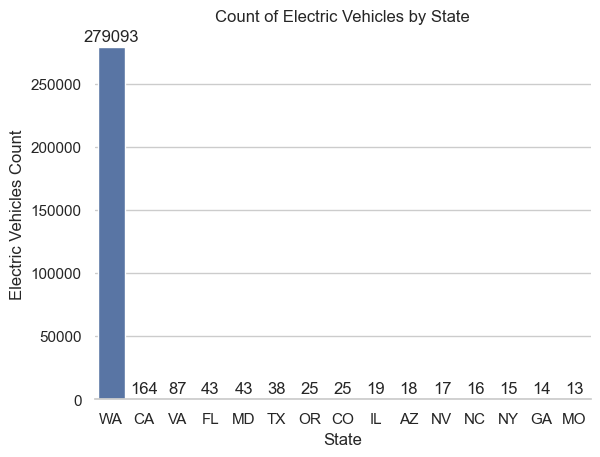

In [4]:
top_fifteen_states = duckdb.sql("""
                                SELECT State, COUNT(*) AS Count from df
                                GROUP BY State
                                ORDER BY Count DESC
                                LIMIT 15
                                """).df()

show_plot(False, False, top_fifteen_states, 'State', 'Count', 'Count of Electric Vehicles by State', y_axis = 'Electric Vehicles Count', despine = 'left', plot_type='bar')

**Analysis**

Washington seems to have the most Electric Vehicle registrations by a huge margin, which indicates that this dataset has significantly more data to explore relevant to EVs in Washington.

We can investigate the distribution of EVs in the other 14 states by using a seperate bar chart. The results from the bar chart above indicates that our analysis by the end of this file may inadvertantly skew towards EVs in Washington. We can drill down on the counties within Washington to see which counties and cities are best for Electric Vehicle dealership presence.

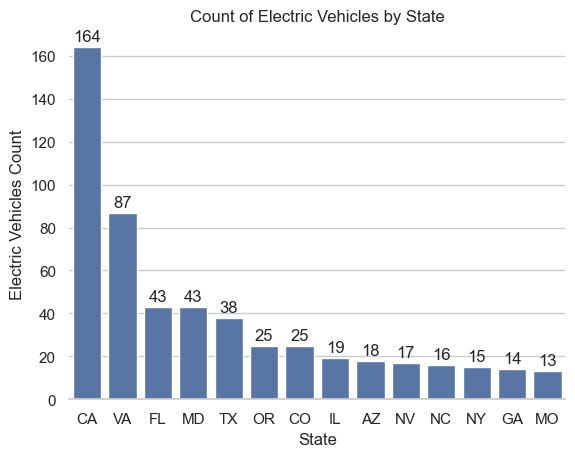

In [5]:
show_plot(False, False, top_fifteen_states[1:], 'State', 'Count', 'Count of Electric Vehicles by State', y_axis = 'Electric Vehicles Count', despine="left", plot_type='bar')

**Analysis**

California and Virginia seem to have the most EVs following Washington, with California having almost double the amount of registered EVs as Virginia (of registered EVs in Washington).

This indicates that if new dealerships or EV manufacturers were to enter the US market, their best targets could be Washington, California, or Virginia. Dealerships and manufacturers that would like a competitive edge against Washington dealerships would best be present in California and Virginia, as these are states which have the highest registration rates from outside of Washington.

The preference of Electric Vehicle Type (PHEVs and BEVs) could also be analyzed across these states with a choropleth chart of the USA. We can also further this geographic investigation by looking into EV distribution within counties and cities in the future.

#### Which states show a stronger preference for BEVs and PHEVs, and how should that influence dealership inventory strategy? (w/ Plotly)

In [6]:
electric_types = duckdb.sql("""
                            SELECT State, MODE("Electric Vehicle Type") AS Type from df
                            GROUP BY State
                            """).df()
electric_types.head()

,State,Type
0,NC,Battery Electric (BEV)
1,HI,Battery Electric (BEV)
2,CO,Battery Electric (BEV)
3,WY,Battery Electric (BEV)
4,MD,Battery Electric (BEV)


We can also plot the distribution of the vehicles using plotly, as can be seen here in their documentation: https://plotly.com/python/choropleth-maps/

In [7]:
fig = px.choropleth(data_frame=electric_types, locations='State', locationmode="USA-states", color='Type', scope='usa')
fig

![BEV vs PHEV Distribution Across United States](../pics/bevs_vs_phevs.png)

**Analysis**

The top three states (Washington, California, and Virgina) we found by the count of EVs in the previous chart seem to all prefer Battery Electric, with a handful of states prefering Plug-In Hybrid.

This indicates that if Electric Vehicle dealerships were to have multiple branches, or new EV manufacturers were to enter the market, they can target states that prefer Battery Electric as they seem to be preferred across the United States more often than Plugin Hybrid vehicles. 

If dealerships or manufacturers want to target a smaller niche to have a competitive edge, they could choose to sell Plugin Hybrid vehicles in the handful of states that prefer Plugin Hybrids.

#### Which are the counties (of those states) have the highest EV count? How does this influence dealership placement?

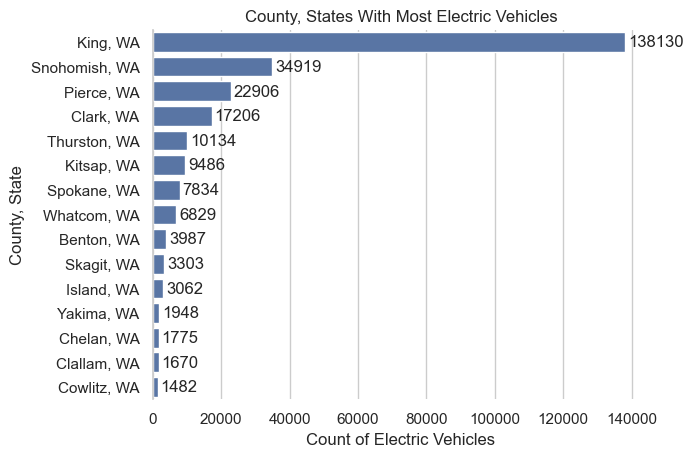

In [8]:
pop_county_states = duckdb.sql("""
                    SELECT County, State, COUNT(County) AS Count FROM df
                    GROUP BY County, State
                    ORDER BY Count DESC
                    LIMIT 15
                    """).df()
pop_county_states["County, State"] = pop_county_states["County"] + ", " + pop_county_states["State"]
show_plot(False, False, pop_county_states, 'Count', 'County, State', 'County, States With Most Electric Vehicles', x_axis='Count of Electric Vehicles', despine='bottom', plot_type='bar')

What this chart shows, no interpretation (1-2 sentences)

Key Insight (2-4 sentences) - What matters, what stands out?

Business Implication (1-3 Sentences) - So what? What should someone do with this?

#### Which cities (of those counties) have the highest amount of EVs, split by PHEVs and BEVs? Which cities represent the strongest EV demand hotspots for dealership placement?

First, let's see the top ten counties and cities with the highest amount of EVs:

In [9]:
top_counties_cities = duckdb.sql("""
                            SELECT County, City, State, COUNT(*) AS Count from df
                            GROUP BY County, City, State
                            ORDER BY Count DESC
                            LIMIT 10
                            """).df()
top_counties_cities

,County,City,State,Count
0,King,Seattle,WA,43250
1,King,Bellevue,WA,13683
2,Clark,Vancouver,WA,10395
3,King,Redmond,WA,9606
4,King,Kirkland,WA,7978
5,King,Sammamish,WA,7798
6,King,Renton,WA,7647
7,Snohomish,Bothell,WA,7273
8,Thurston,Olympia,WA,6508
9,Pierce,Tacoma,WA,6072


Since the state in the above table is always Washington, we can leave the State out in the following step.

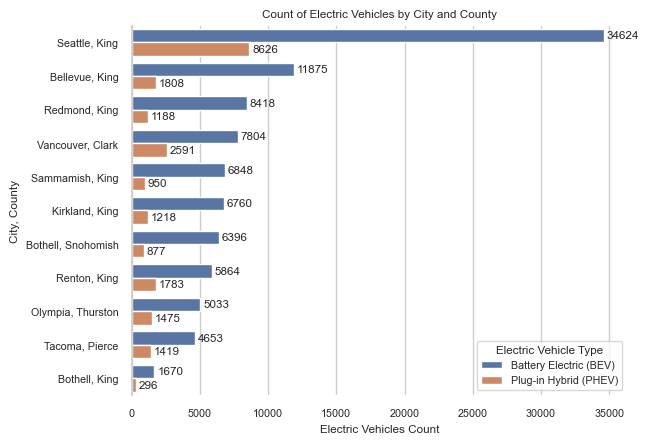

In [10]:
# Now, we use IN with the counties we found in the first step like so: https://stackoverflow.com/a/29749286
top_counties = top_counties_cities['County'].tolist()
top_cities = top_counties_cities['City'].tolist()

top_evs_county_city = duckdb.sql(f"""
                            SELECT County, City, "Electric Vehicle Type", COUNT(*) AS Count from df
                            WHERE County IN {top_counties} AND City IN {top_cities}
                            GROUP BY County, City, "Electric Vehicle Type"
                            ORDER BY Count DESC
                            """).df()

top_evs_county_city["City, County"] = top_evs_county_city["City"] + ", " + top_evs_county_city["County"] 
show_plot(False, True, top_evs_county_city, 'Count', 'City, County', 'Count of Electric Vehicles by City and County', x_axis = 'Electric Vehicles Count', hue = 'Electric Vehicle Type', despine='bottom', plot_type='bar')

From the above graph, we can see...

### Analyzing Brands & Models

#### What are the top ten most popular brands of Electric Vehicles?

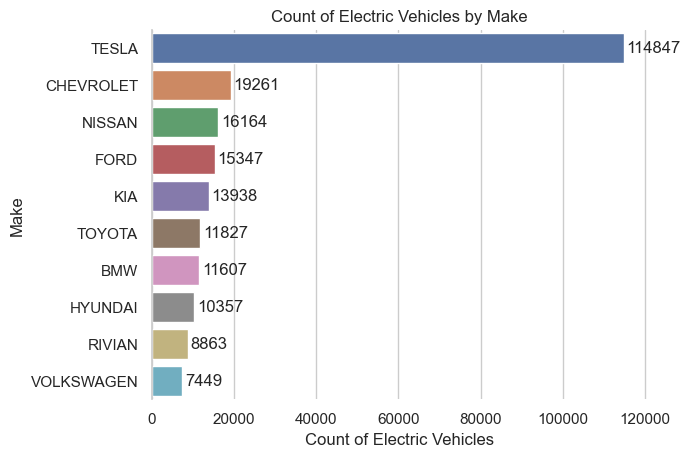

In [11]:
top_10_makes = duckdb.sql("""
                            SELECT Make, COUNT(*) AS Count from df
                            GROUP BY Make
                            ORDER BY Count DESC
                            LIMIT 10
                            """).df()

top_makes = top_10_makes['Make'].tolist()
show_plot(True, False, top_10_makes, 'Count', 'Make', 'Count of Electric Vehicles by Make', x_axis='Count of Electric Vehicles', despine='bottom', hue='Make', plot_type='bar')

#### Of those brands, which EV models should dealerships prioritize based on regional demand patterns?

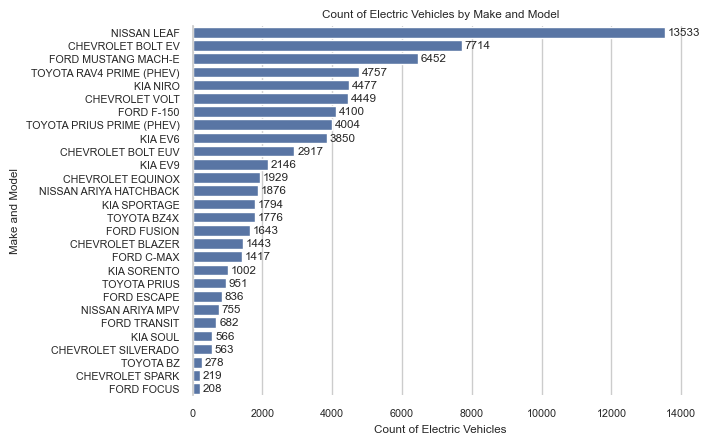

In [12]:
pop_models = duckdb.sql(f"""
                            SELECT Make, Model, COUNT(*) AS Count from df
                            WHERE Make in {top_makes[:6]} AND Make <> 'TESLA'
                            GROUP BY Make, Model
                            HAVING Count > 200
                            ORDER BY Count DESC
                            """).df()
pop_models["Make and Model"] = pop_models["Make"] + " " + pop_models["Model"]
show_plot(False, True, pop_models, 'Count', 'Make and Model', 'Count of Electric Vehicles by Make and Model', x_axis='Count of Electric Vehicles', despine='bottom', plot_type='bar')

#### How does the count of EVs model years change over time in the top 10 counties?

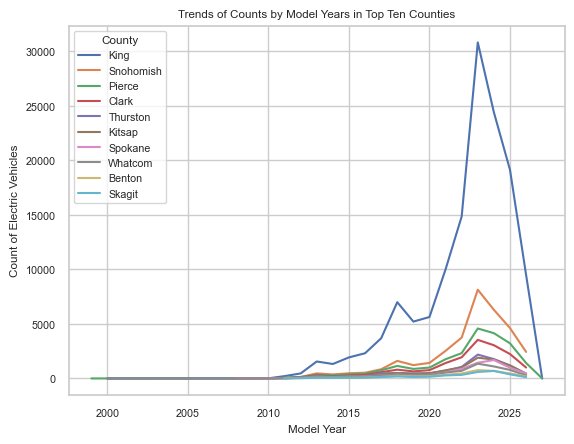

In [13]:
top_10_counties = duckdb.sql("""
                            SELECT County, COUNT(*) AS Count from df
                            GROUP BY County
                            ORDER BY Count DESC
                            LIMIT 10
                            """).df()
county_list = top_10_counties['County'].tolist()

county_vs_year = duckdb.sql(f"""
                            SELECT County, "Model Year", COUNT(*) AS Count from df
                            WHERE County IN {county_list}
                            GROUP BY County, "Model Year"
                            ORDER BY Count DESC
                            """).df()
show_plot(True, True, county_vs_year, 'Model Year', 'Count', 'Trends of Counts by Model Years in Top Ten Counties', x_axis='Model Year', y_axis='Count of Electric Vehicles', hue='County', plot_type='line')

#### Which top five non-Tesla brands dominate EV demand in high-adoption regions in the top five counties we found earlier (in Washington State)? How should this influence dealerships and their strategy?

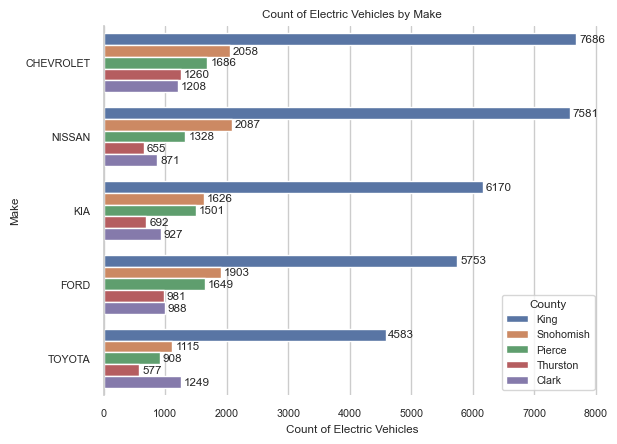

In [14]:
pop_non_tesla = duckdb.sql(f"""
                            SELECT Make, County, COUNT(*) AS Count from df
                            WHERE County IN {county_list[:5]} AND Make in {top_makes[:6]} AND Make <> 'TESLA'
                            GROUP BY Make, County
                            ORDER BY Count DESC
                            """).df()
show_plot(False, True, pop_non_tesla, 'Count', 'Make', 'Count of Electric Vehicles by Make', x_axis='Count of Electric Vehicles', despine='bottom', hue='County', plot_type='bar')

### Analyzing PHEV and BEV Split

#### How have the number of PHEVs and BEVs changed over the years?

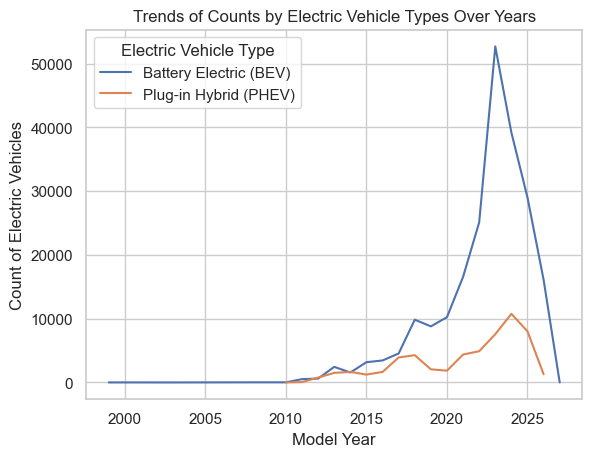

In [15]:
yearly_dist = duckdb.sql("""
                    SELECT "Electric Vehicle Type", "Model Year", COUNT("Model Year") AS Count FROM df
                    GROUP BY "Electric Vehicle Type", "Model Year"
                    ORDER BY Count DESC
                    """).df()
show_plot(True, False, yearly_dist, 'Model Year', 'Count', 'Trends of Counts by Electric Vehicle Types Over Years', x_axis='Model Year', y_axis='Count of Electric Vehicles', hue='Electric Vehicle Type', plot_type='line')

### Analyzing Electric Ranges

#### How does Minimum and Maximum Electric Ranges change for the top EV brands?

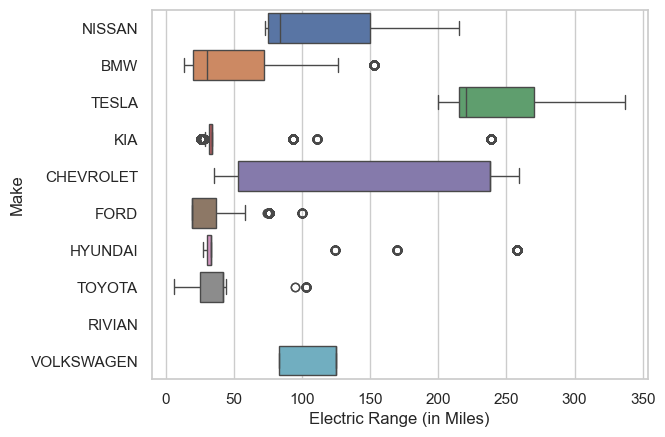

In [16]:
elec_boxplot = duckdb.sql(f"""
                    SELECT Make, "Electric Range (in Miles)" from df
                    WHERE Make IN {top_makes}
                    """).df()
sns.boxplot(elec_boxplot, x='Electric Range (in Miles)', y='Make', hue='Make')
plt.show()

#### How has Electric Range changed across model years and Electric Vehicle Type, and what does this suggest about evolving consumer expectations?

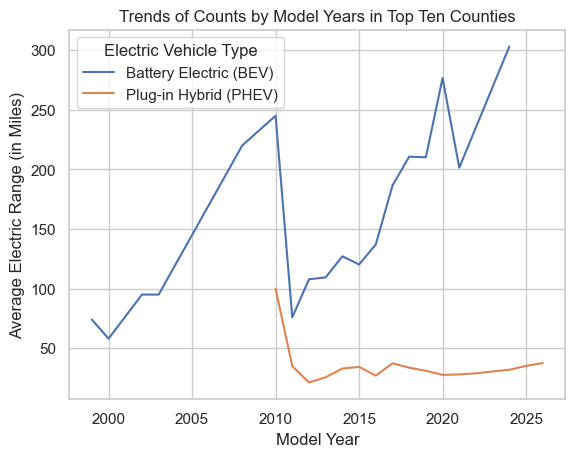

In [17]:
pop_city = duckdb.sql("""
                    SELECT "Model Year", "Electric Vehicle Type", AVG("Electric Range (in Miles)") AS Average from df_elec
                    GROUP BY "Model Year", "Electric Vehicle Type"
                    """).df()
show_plot(True, False, pop_city, 'Model Year', 'Average', 'Trends of Counts by Model Years in Top Ten Counties', y_axis='Average Electric Range (in Miles)', hue='Electric Vehicle Type', plot_type='line')

**Dealership Analysis**

These questions look at the most popular counties and cities in Washington State, as we saw that the demand for EVs in Washington State was highest.

## Key Insights

## Conclusions and Next Steps